Merwin Abba B. LLorin

2ECE-A

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# dataset
df = pd.read_csv("board2.csv")

#Add a derived Average column
board = df.copy()
board["Average"] = board[["Math", "Electronics", "GEAS", "Communication"]].mean(axis=1)

print("Shape of the dataset:", board.shape)
board.head()

Shape of the dataset: (30, 9)


,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00


In [7]:
print("Track     :", board["Track"].unique().tolist())
print("Gender    :", board["Gender"].unique().tolist())
print("Hometown  :", board["Hometown"].unique().tolist())

Track     : ['Instrumentation', 'Communication', 'Microelectronics']
Gender    : ['Male', 'Female']
Hometown  : ['Luzon', 'Mindanao', 'Visayas']


### A. VISAYAS COMMUNICATION DATAFRAME

In [15]:
# Filter students who are from Visayas and track is communication
VisComm = board[(board["Hometown"] == "Visayas") & (board["Track"] == "Communication")][
    ["Name", "Gender", "Math", "Electronics", "Average"]
]

VisComm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


In [16]:
print("Number of rows in VisComm:", VisComm.shape[0])

Number of rows in VisComm: 5


### B. VISAYAS FEMALE DATAFRAME

In [27]:
# Filter students who are from Visayas and Gender is female
VisFemale = board[(board["Hometown"] == "Visayas") & (board["Gender"] == "Female")][
    ["Name", "Track", "GEAS", "Electronics", "Average"]
]

VisFemale

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


### C. CATEGORY-AVERAGE VISUALIZATION

#### a. compute the mean of Average

In [30]:
VisFemale_60 = VisFemale[VisFemale["Average"] >= 60]

VisFemale_60

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


#### Display Three Summary Tables

In [32]:
# Mean of Average for every category
mean_by_track = board.groupby("Track")["Average"].mean()
mean_by_gender = board.groupby("Gender")["Average"].mean()
mean_by_hometown = board.groupby("Hometown")["Average"].mean()

display(mean_by_track.round(2).to_frame("Mean Average"))
display(mean_by_gender.round(2).to_frame("Mean Average"))
display(mean_by_hometown.round(2).to_frame("Mean Average"))

,Mean Average
Track,
Communication,67.97
Instrumentation,65.22
Microelectronics,67.50


,Mean Average
Gender,
Female,66.62
Male,67.18


,Mean Average
Hometown,
Luzon,68.08
Mindanao,66.68
Visayas,65.75


#### C. Bar charts: Mean Average by Track, by Gender, Hometown

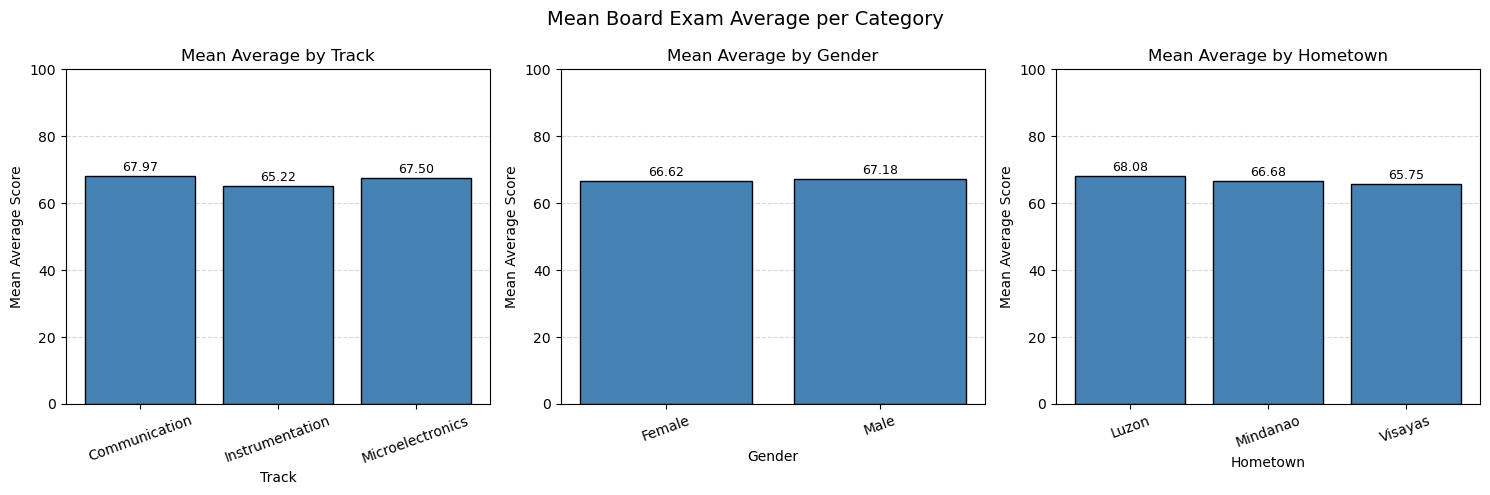

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

summaries = [
    (mean_by_track, "Track", "Mean Average by Track"),
    (mean_by_gender, "Gender", "Mean Average by Gender"),
    (mean_by_hometown, "Hometown", "Mean Average by Hometown"),
]

for ax, (data, feature, title) in zip(axes, summaries):
    ax.bar(data.index, data.values, color="steelblue", edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Mean Average Score")
    ax.set_ylim(0, 100)               # consistent scale for all three charts
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

    # Title for each bar
    for x, y in zip(data.index, data.values):
        ax.text(x, y + 1.5, f"{y:.2f}", ha="center", fontsize=9)

fig.suptitle("Mean Board Exam Average per Category", fontsize=14)
plt.tight_layout()
plt.show()

#### D. Highest Sample Mean

In [46]:
for name, data in [("Track", mean_by_track), ("Gender", mean_by_gender), ("Hometown", mean_by_hometown)]:
    print(f"{name}: highest sample mean is {data.idxmax()} ({data.max():.2f})")

Track: highest sample mean is Communication (67.97)
Gender: highest sample mean is Male (67.18)
Hometown: highest sample mean is Luzon (68.08)
